# Shapley Values for Transformed Features of MOJO Models Demo

This example demonstrates how to interpret a Driverless AI MOJO model using the H2O Sonar library and retrieve the data and plot with transformed features importances.

In [1]:
import os
import logging

import datatable
import daimojo
import webbrowser

from h2o_sonar import interpret
from h2o_sonar.lib.api import commons
from h2o_sonar.lib.api import explainers
from h2o_sonar.explainers import transformed_fi_shapley_explainer as explainer
from h2o_sonar.lib.api.models import ModelApi

In [2]:
# explainer description
interpret.describe_explainer(explainer.ShapleyMojoTransformedFeatureImportanceExplainer)

{'id': 'h2o_sonar.explainers.transformed_fi_shapley_explainer.ShapleyMojoTransformedFeatureImportanceExplainer',
 'name': 'ShapleyMojoTransformedFeatureImportanceExplainer',
 'display_name': 'Shapley Values for Transformed Features of MOJO Models',
 'tagline': 'ShapleyMojoTransformedFeatureImportanceExplainer.',
 'description': 'Shapley explanations are a technique with credible theoretical support that presents consistent global and local variable contributions. Local numeric Shapley values are calculated by tracing single rows of data through a trained tree ensemble and aggregating the contribution of each input variable as the row of data moves through the trained ensemble. For regression tasks Shapley values sum to the prediction of the (Driverless AI) MOJO model. For classification problems, Shapley values sum to the prediction of the MOJO model before applying the link function. Global Shapley values are the average of the absolute local Shapley values over every row of a data se

## Interpretation

In [3]:
# dataset
dataset_path = "../../data/predictive/creditcard.csv"
target_col = "default payment next month"

# model
mojo_path = "../../data/predictive/models/creditcard-binomial.mojo"
mojo_model = daimojo.model(mojo_path)
model = ModelApi().create_model(
    model_src=mojo_model,
    target_col=target_col,
    used_features=list(mojo_model.feature_names),
)

# results
results_location = "./results"
os.makedirs(results_location, exist_ok=True)

In [4]:
interpretation = interpret.run_interpretation(
    dataset=dataset_path,
    model=model,
    target_col=target_col,
    results_location=results_location,
    explainers=[explainer.ShapleyMojoTransformedFeatureImportanceExplainer.explainer_id()],
    log_level=logging.INFO,
)

/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:1: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from ragas.metrics._answer_correctness import AnswerCorrectness, answer_correctness
/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:4: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain.pydantic_v1 module was a compatibility shim for pydantic 

## Explainer Result

In [5]:
# retrieve the result
result = interpretation.get_explainer_result(
    explainer.ShapleyMojoTransformedFeatureImportanceExplainer.explainer_id()
)

In [6]:
# open interpretation HTML report in web browser
webbrowser.open(interpretation.result.get_html_report_location())

True

In [7]:
# summary
result.summary()

{'id': 'h2o_sonar.explainers.transformed_fi_shapley_explainer.ShapleyMojoTransformedFeatureImportanceExplainer',
 'name': 'ShapleyMojoTransformedFeatureImportanceExplainer',
 'display_name': 'Shapley Values for Transformed Features of MOJO Models',
 'tagline': 'ShapleyMojoTransformedFeatureImportanceExplainer.',
 'description': 'Shapley explanations are a technique with credible theoretical support that presents consistent global and local variable contributions. Local numeric Shapley values are calculated by tracing single rows of data through a trained tree ensemble and aggregating the contribution of each input variable as the row of data moves through the trained ensemble. For regression tasks Shapley values sum to the prediction of the (Driverless AI) MOJO model. For classification problems, Shapley values sum to the prediction of the MOJO model before applying the link function. Global Shapley values are the average of the absolute local Shapley values over every row of a data se

In [8]:
# parameters
result.params()

{'sample_size': 100000,
 'calculate_predictions': False,
 'fast_approx_contrib': True}

### Display Data

In [9]:
result.data()

,feature,importance
,▪▪▪▪,▪▪▪▪▪▪▪▪
0,10_PAY_0,0.484314
1,11_PAY_2,0.177288
2,8_LIMIT_BAL,0.14293
3,19_PAY_AMT4,0.125988
4,17_PAY_AMT2,0.109839
5,1_BILL_AMT1,0.0856685
6,12_PAY_3,0.0460469
7,18_PAY_AMT3,0.0405643
8,15_PAY_6,0.035129


### Plot Feature Importance Data

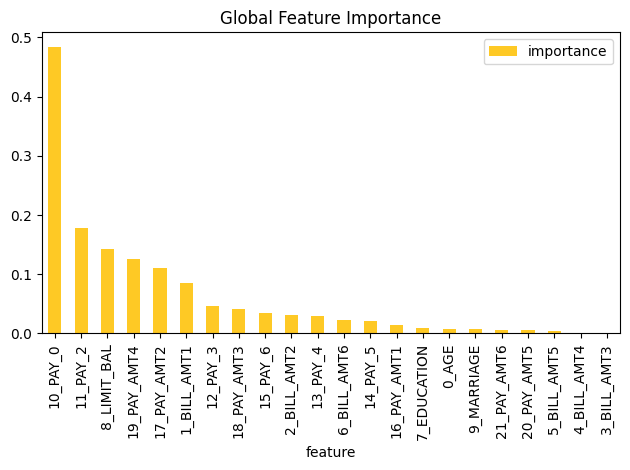

In [10]:
result.plot()

### Save Explainer Log and Data

In [11]:
# save the explainer log
log_file_path = "./feature-importance-demo.log"
result.log(path=log_file_path)

In [12]:
!cat $log_file_path

In [13]:
# save the explainer data
result.zip(file_path="./feature-importance-demo-archive.zip")

In [14]:
!unzip -l feature-importance-demo-archive.zip

Archive:  feature-importance-demo-archive.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     3788  2026-01-29 15:59   explainer_h2o_sonar_explainers_transformed_fi_shapley_explainer_ShapleyMojoTransformedFeatureImportanceExplainer_461b7b1c-e2b5-48ce-b144-c168e19714d8/result_descriptor.json
        2  2026-01-29 15:59   explainer_h2o_sonar_explainers_transformed_fi_shapley_explainer_ShapleyMojoTransformedFeatureImportanceExplainer_461b7b1c-e2b5-48ce-b144-c168e19714d8/problems/problems_and_actions.json
      110  2026-01-29 15:59   explainer_h2o_sonar_explainers_transformed_fi_shapley_explainer_ShapleyMojoTransformedFeatureImportanceExplainer_461b7b1c-e2b5-48ce-b144-c168e19714d8/global_html_fragment/text_html.meta
     4636  2026-01-29 15:59   explainer_h2o_sonar_explainers_transformed_fi_shapley_explainer_ShapleyMojoTransformedFeatureImportanceExplainer_461b7b1c-e2b5-48ce-b144-c168e19714d8/global_html_fragment/text_html/explanation.html
    32993  2026-01-29 